#Emotion Classification with RNNs, LSTMs and GRUs

#Classifying text into 6 emotions (sadness, joy, love, anger, fear, surprise) by comparing plain recurrent models before building an Advanced Bidrectional GRU


In [3]:
!pip install datasets -q

#Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Dataset load krne mein help karegi

from datasets import load_dataset

In [4]:
#Loaded data from Hugging face
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [5]:
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [7]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)

In [8]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

In [9]:

df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

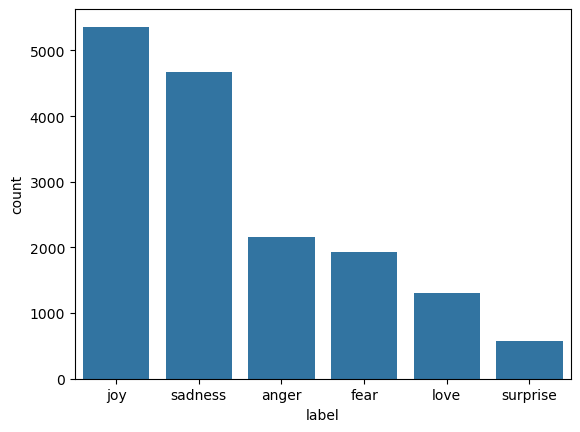

In [10]:

sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [11]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


#4.Data Preprocessing - Using NLP
#Tokenize text, pad sequences to max length 50 and convert labels to Numpy arrays.

In [12]:
%pip install tensorflow -q

Note: you may need to restart the kernel to use updated packages.


In [13]:
#Data Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences 
max_words = 10000

#In tokenization new words are marked as unknown
tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

#Input size is not same then padding is done (RNN).ipynb
padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post' ,truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post' ,truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f'Vocabulary Size: {len(tokenizer.word_index)}')
print(f'Max Sentence Length: {padded_train_sequence.shape[1]}')




Vocabulary Size: 15213
Max Sentence Length: 50


In [14]:
#Shared Training Utilities
#Compute balanced class weights to handle dataset skew and setup early stopping.

#RNN dont have class weight

from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight= 'balanced',
    classes     = np.unique(train_labels),
    y           = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [15]:
#it trains until changes stop
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights= True
)

In [16]:
#Simple model of RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential(
    [
        Embedding(input_dim= max_words, output_dim= 120, input_length= 50),
        
        SimpleRNN(units=128, return_sequences=True),
        Dropout(0.5),
        SimpleRNN(units=64),
        Dropout(0.5),
        Dense(units=num_classes, activation='softmax')#Output Layer
    ]
)

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

c:\Users\tanma\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
#RNN reads one by one. To maintain previous --> return_sequences=True,

In [18]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1586 - loss: 2.0400 - val_accuracy: 0.1320 - val_loss: 1.7785
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1451 - loss: 1.8930 - val_accuracy: 0.1085 - val_loss: 1.7389
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.1316 - loss: 1.8265 - val_accuracy: 0.2760 - val_loss: 1.7820
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.1409 - loss: 1.8088 - val_accuracy: 0.0540 - val_loss: 1.7905
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.1332 - loss: 1.8046 - val_accuracy: 0.0815 - val_loss: 1.8082
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1085 - loss: 1.7389
RNN Loss: 1.7389317750930786
RNN Accuracy: 0.10849999636411667


In [19]:
#RNN is not suitable

In [20]:
#Lstm stores output of previous results, powerful than rnn

In [21]:
#2.LSTM 
lstm_model = Sequential([
    Embedding(input_dim= max_words, output_dim = 128, input_length= 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs =20,
    batch_size =32,
    
    class_weight=class_weight_dict,
    callbacks=[early_stopping]

)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f'LSTM Loss: {lstm_loss}')
print(f'LSTM Accuracy: {lstm_accuracy}')

Epoch 1/20


c:\Users\tanma\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 96ms/step - accuracy: 0.1651 - loss: 1.7954 - val_accuracy: 0.0330 - val_loss: 1.7865
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.1618 - loss: 1.7937 - val_accuracy: 0.1605 - val_loss: 1.7871
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - accuracy: 0.1724 - loss: 1.7892 - val_accuracy: 0.1355 - val_loss: 1.7896
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - accuracy: 0.2082 - loss: 1.6901 - val_accuracy: 0.2855 - val_loss: 1.6625
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.3654 - loss: 1.3082 - val_accuracy: 0.4385 - val_loss: 1.3827
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - accuracy: 0.5361 - loss: 0.9310 - val_accuracy: 0.6905 - val_loss: 0.9608
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 264ms/step - accuracy: 0.6879 - loss: 0.6704 - val_accuracy: 0.7475 - val_loss: 0.7688
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.7885 - loss: 0.5080 - val_accur

In [22]:
#3.GRU 
gru_model = Sequential([
    Embedding(input_dim= max_words, output_dim = 128, input_length= 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs =20,
    batch_size =32,
    
    class_weight=class_weight_dict,
    callbacks=[early_stopping]

)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f'GRU Loss: {gru_loss}')
print(f'GRU Accuracy: {gru_accuracy}')

Epoch 1/20


c:\Users\tanma\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 124ms/step - accuracy: 0.1524 - loss: 1.7964 - val_accuracy: 0.0340 - val_loss: 1.8096
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 117ms/step - accuracy: 0.1439 - loss: 1.7957 - val_accuracy: 0.2900 - val_loss: 1.7670
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.1689 - loss: 1.7944 - val_accuracy: 0.0345 - val_loss: 1.8123
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.1656 - loss: 1.7938 - val_accuracy: 0.2890 - val_loss: 1.7678
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.1464 - loss: 1.7910 - val_accuracy: 0.3235 - val_loss: 1.7780
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2900 - loss: 1.7670
GRU Loss: 1.7670413255691528
GRU Accuracy: 0.28999999165534973


In [23]:
#Phase 1 ranking and selection
#Rank foundational models to pick the best base cell for Phase 2.
result_df = pd.DataFrame({
    'Model': ['RNN','LSTM','GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.517632,0.8560
2,GRU,1.767041,0.2900
0,RNN,1.738932,0.1085


In [ ]:
#Reading is done both left to right and vice versa 

In [24]:
#Building Advanced Bidirectional GRU
#Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regulation.
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim= max_words, output_dim= 300, input_length= 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer

])

BiGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.summary()


c:\Users\tanma\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size= 32,
    class_weight = class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 140ms/step - accuracy: 0.5866 - loss: 1.0351 - val_accuracy: 0.8935 - val_loss: 0.3706
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 131ms/step - accuracy: 0.9193 - loss: 0.2302 - val_accuracy: 0.9180 - val_loss: 0.2374
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 129ms/step - accuracy: 0.9492 - loss: 0.1351 - val_accuracy: 0.9195 - val_loss: 0.2313
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 138ms/step - accuracy: 0.9634 - loss: 0.1005 - val_accuracy: 0.9265 - val_loss: 0.2135
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 138ms/step - accuracy: 0.9731 - loss: 0.0751 - val_accuracy: 0.9210 - val_loss: 0.2341
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 99s 125ms/step - accuracy: 0.9781 - loss: 0.0617 - val_accuracy: 0.9215 - val_loss: 0.2808
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 129ms/step - accuracy: 0.9779 - loss: 0.0624 - val_accuracy: 0.9110 - val_loss: 0.3236


In [26]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f'BiGRU Loss: {BiGRU_loss}')
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9265 - loss: 0.2135
BiGRU Loss: 0.21352361142635345
BiGRU Accuracy: 0.9265000224113464


#Overall evaluation and big analysis


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


<Axes: >

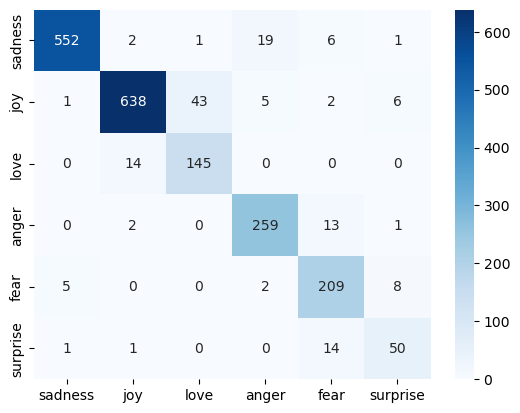

In [34]:
#Confusion Metrics(Rows Count and Normalized %)
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)


In [39]:
#Final Predictions
#Test the winning model on unseen sample sentences.
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
    print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [46]:
#Save model and tokenizer
import os 
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)#Folder will have exported files

#Save BiGRU model
BiGRU.save(os.path.join(model_dir, "BiGRU_Model.keras"))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
    pickle.dump(tokenizer, file)



In [ ]:
#Server start ---> Fastapi app creation ---> Lifespan event Run:
#                                                               1.Load BiGRU model
#                                                               2.Load tokenization
#Api ready to use


#https://localhost:8000 ---> Get '\'(Homepage) ---> Serve  index.html
#user type: 'I am bad!!'
#Post('\Predict')
#Validate Request(Pydantic)
#Preprocess text: lower_case + Punctutations
#Tokenizer: words to number
#Padded Sequence
#BiGRU model
#BiGRU 
#argmax to get max probability
#show on docs 
